##Menggunakan EfficientNetB0 dengan SVM di Dataset Baru

#Import Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf "/content/dataset"
!rsync -ah --info=progress2 "/content/drive/MyDrive/dataset/" "/content/dataset/"

        202.53M 100%  109.83kB/s    0:30:00 (xfr#7500, to-chk=0/7504)


In [ ]:
DATASET_PATH = "/content/dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42

#Import Library

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import random
import joblib

#Cek Dataset

In [ ]:
dataset_dir = Path(DATASET_PATH)

class_counts = {}

for class_folder in dataset_dir.iterdir():
    if class_folder.is_dir():
        total_images = len(list(class_folder.glob("*")))
        class_counts[class_folder.name] = total_images

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Kelas", "Jumlah"]
)

df_counts

,Kelas,Jumlah
0,Terisi,2500
1,Kosong,2500
2,Penuh,2500


In [ ]:
image_paths = []
labels = []

valid_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]

for class_folder in dataset_dir.iterdir():
    if class_folder.is_dir():
        for ext in valid_extensions:
            for img_path in class_folder.glob(ext):
                image_paths.append(str(img_path))
                labels.append(class_folder.name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

df.head()

,image_path,label
0,/content/dataset/Terisi/Terisi_aug_0371.jpg,Terisi
1,/content/dataset/Terisi/Terisi_aug_0310.jpg,Terisi
2,/content/dataset/Terisi/Terisi_aug_1470.jpg,Terisi
3,/content/dataset/Terisi/Terisi_aug_0046.jpg,Terisi
4,/content/dataset/Terisi/Terisi_aug_1600.jpg,Terisi


In [ ]:
print("Total gambar:", len(df))
print(df["label"].value_counts())

Total gambar: 7500
label
Terisi    2500
Kosong    2500
Penuh     2500
Name: count, dtype: int64


In [ ]:
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["label"])

print("Daftar kelas:", label_encoder.classes_)
df.head()

Daftar kelas: ['Kosong' 'Penuh' 'Terisi']


,image_path,label,label_encoded
0,/content/dataset/Terisi/Terisi_aug_0371.jpg,Terisi,2
1,/content/dataset/Terisi/Terisi_aug_0310.jpg,Terisi,2
2,/content/dataset/Terisi/Terisi_aug_1470.jpg,Terisi,2
3,/content/dataset/Terisi/Terisi_aug_0046.jpg,Terisi,2
4,/content/dataset/Terisi/Terisi_aug_1600.jpg,Terisi,2


In [ ]:
class_names = (
    df[["label_encoded", "label"]]
    .drop_duplicates()
    .sort_values("label_encoded")["label"]
    .tolist()
)

print(class_names)

['Kosong', 'Penuh', 'Terisi']


#Split Dataset

In [ ]:
X = df["image_path"].values
y = df["label_encoded"].values

X_train_val, X_test, y_train_val, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    stratify=y_train_val,
    random_state=SEED
)

print("Jumlah train:", len(X_train))
print("Jumlah validation:", len(X_val))
print("Jumlah test:", len(X_test))

Jumlah train: 5250
Jumlah validation: 750
Jumlah test: 1500


In [ ]:
def load_and_preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

base_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
def extract_features(image_paths, batch_size=32):
    features = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i + batch_size]
        batch_images = []

        for img_path in batch_paths:
            img_array = load_and_preprocess_image(img_path)
            batch_images.append(img_array)

        batch_images = np.array(batch_images)

        batch_features = base_model.predict(batch_images, verbose=0)
        features.append(batch_features)

        print(f"Processed {min(i + batch_size, len(image_paths))}/{len(image_paths)} images")

    features = np.vstack(features)
    return features

In [ ]:
X_train_features = extract_features(X_train, batch_size=BATCH_SIZE)
X_val_features = extract_features(X_val, batch_size=BATCH_SIZE)
X_test_features = extract_features(X_test, batch_size=BATCH_SIZE)

print("Shape fitur train:", X_train_features.shape)
print("Shape fitur validation:", X_val_features.shape)
print("Shape fitur test :", X_test_features.shape)

Processed 64/5250 images
Processed 128/5250 images
Processed 192/5250 images
Processed 256/5250 images
Processed 320/5250 images
Processed 384/5250 images
Processed 448/5250 images
Processed 512/5250 images
Processed 576/5250 images
Processed 640/5250 images
Processed 704/5250 images
Processed 768/5250 images
Processed 832/5250 images
Processed 896/5250 images
Processed 960/5250 images
Processed 1024/5250 images
Processed 1088/5250 images
Processed 1152/5250 images
Processed 1216/5250 images
Processed 1280/5250 images
Processed 1344/5250 images
Processed 1408/5250 images
Processed 1472/5250 images
Processed 1536/5250 images
Processed 1600/5250 images
Processed 1664/5250 images
Processed 1728/5250 images
Processed 1792/5250 images
Processed 1856/5250 images
Processed 1920/5250 images
Processed 1984/5250 images
Processed 2048/5250 images
Processed 2112/5250 images
Processed 2176/5250 images
Processed 2240/5250 images
Processed 2304/5250 images
Processed 2368/5250 images
Processed 2432/52

#Training Model SVM

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=SEED))
])

param_grid = {
    "svm__kernel": ["rbf"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_features, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

svm_model = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV Accuracy: 0.9718095238095238


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_val_pred = svm_model.predict(X_val_features)

print("===== Evaluasi Validation Set =====")
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=class_names))

===== Evaluasi Validation Set =====
Validation Accuracy: 0.9773333333333334
              precision    recall  f1-score   support

      Kosong       0.98      0.97      0.98       250
       Penuh       0.98      0.98      0.98       250
      Terisi       0.97      0.98      0.98       250

    accuracy                           0.98       750
   macro avg       0.98      0.98      0.98       750
weighted avg       0.98      0.98      0.98       750



===== Evaluasi Test Set =====
Test Accuracy: 0.968
              precision    recall  f1-score   support

      Kosong       0.98      0.97      0.97       500
       Penuh       0.97      0.96      0.97       500
      Terisi       0.95      0.97      0.96       500

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



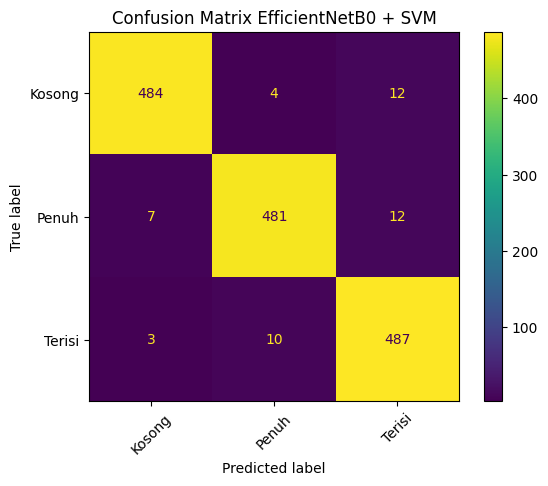

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_pred = svm_model.predict(X_test_features)

print("===== Evaluasi Test Set =====")
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix EfficientNetB0 + SVM")
plt.show()

===== Top 20 Feature Importance EfficientNetB0 + SVM RBF =====


,feature_index_asli,Feature,Importance
22,463,Feature 463,0.041
85,1221,Feature 1221,0.023
25,73,Feature 73,0.022
45,105,Feature 105,0.020
95,416,Feature 416,0.017
24,1202,Feature 1202,0.016
7,1044,Feature 1044,0.016
30,572,Feature 572,0.015
53,187,Feature 187,0.014
35,798,Feature 798,0.014


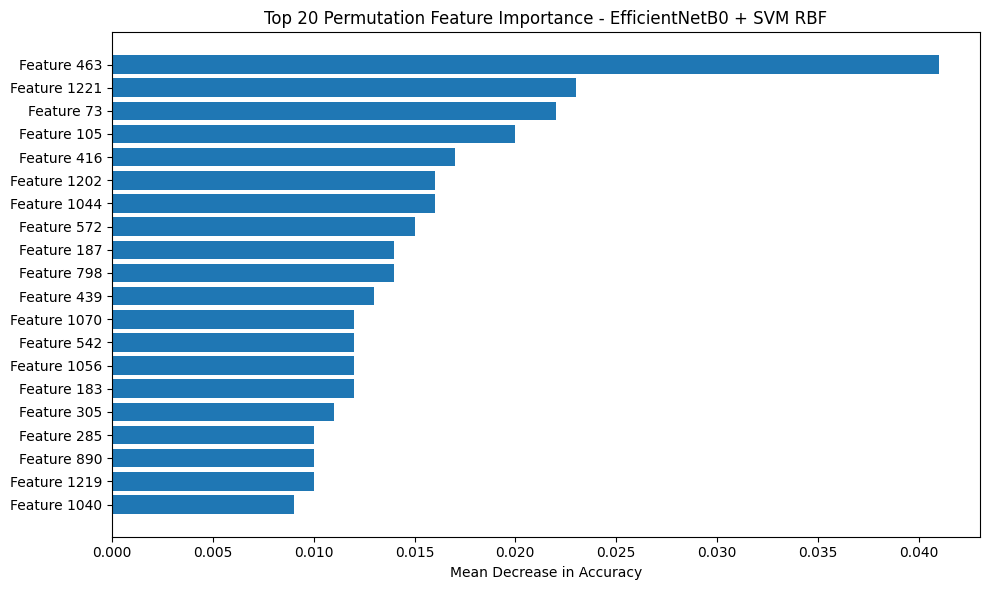

In [ ]:
from sklearn.inspection import permutation_importance

sample_size = min(200, len(X_test_features))

X_test_features = np.array(X_test_features)
X_train_features = np.array(X_train_features)
y_test = np.array(y_test)
y_train = np.array(y_train)

np.random.seed(SEED)
sample_idx = np.random.choice(len(X_test_features), sample_size, replace=False)

X_test_sample = X_test_features[sample_idx]
y_test_sample = y_test[sample_idx]

top_k_features = 100

feature_variance = np.var(X_train_features, axis=0)
candidate_indices = np.argsort(feature_variance)[-top_k_features:]

X_test_candidate = X_test_sample[:, candidate_indices]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_candidate = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True,
        random_state=SEED
    ))
])

X_train_candidate = X_train_features[:, candidate_indices]

svm_candidate.fit(X_train_candidate, y_train)

result = permutation_importance(
    svm_candidate,
    X_test_candidate,
    y_test_sample,
    n_repeats=5,
    random_state=SEED,
    scoring="accuracy",
    n_jobs=-1
)

importance = result.importances_mean

feature_importance_df = pd.DataFrame({
    "feature_index_asli": candidate_indices,
    "Feature": [f"Feature {i}" for i in candidate_indices],
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("===== Top 20 Feature Importance EfficientNetB0 + SVM RBF =====")
display(feature_importance_df.head(20))

top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Mean Decrease in Accuracy")
plt.title("Top 20 Permutation Feature Importance - EfficientNetB0 + SVM RBF")
plt.tight_layout()
plt.show()

In [ ]:
y_train_pred = svm_model.predict(X_train_features)
y_test_pred = svm_model.predict(X_test_features)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

gap_train_test = train_acc - test_acc

print("\nGap Train - Testing:", gap_train_test)

Training Accuracy: 0.9998095238095238
Testing Accuracy : 0.968

Gap Train - Testing: 0.03180952380952384


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/efficientnet_svm_model"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(svm_model, os.path.join(SAVE_DIR, "10-06-2026-FIX-efficientnetb0-svm_model.pkl"))
joblib.dump(label_encoder, os.path.join(SAVE_DIR, "0-06-2026-FIX-efficientnetb0-svm-label_encoder.pkl"))

print("Model EfficientNetB0-SVM dan LabelEncoder berhasil disimpan.")

Model EfficientNetB0-SVM dan LabelEncoder berhasil disimpan.
